In [1]:
import sys
sys.path.append('..')

import copy
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import importlib.util
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, confusion_matrix, ConfusionMatrixDisplay
from src.losses import ReconstructionPIT_MSELoss
from src.dataset import create_train_val_datasets
from src.utils import get_device
from config import (
    small_dataset_path,
    medium_dataset_path,
    large_dataset_path,
    huge_dataset_path,
    TRAIN_SIZE,
    SPLIT_STRATEGY,
    SPLIT_STRATEGY,
    SEED_TRAIN,
    SEED_VAL,
    SPLIT_SEED,
    MAX_K,
    CONSTANT_K,
    BATCH_SIZE,
    NB_OF_STEPS
)

In [2]:
device = get_device()
print(f"Using device : {device}") 

run_name = Path("runs/run_20260722_171651") # SNR Weighting Run (Need to be on the branch "experiments/snr-weighting")
# run_name = Path("runs/run_20260722_171831") # Baseline Run  (Need to be on the branch "experiments/snr-weighting")
# run_name = Path("runs/run_20260722_171449") # Improved Model Run (Replaced LayerNorm by RMSNorm and FiLM) (Need to be on the branch "main" or "experiments/model_tuning")
run_name = Path("runs/run_20260803_105358") # Best Model (Improved Model + Normalized MSE DB Loss + Pet only at t= 0) (Need to be on the branch "db-normalized-loss")

run_path = "../" / run_name / "checkpoints"
model_structure_path = run_path / "model_structure.py"
ckpt_path = run_path / "best_checkpoint.pth"
dataset_path = medium_dataset_path

spec = importlib.util.spec_from_file_location(
    "dynamic_model", model_structure_path
)
dynamic_model_module = importlib.util.module_from_spec(spec)
sys.modules["dynamic_model"] = dynamic_model_module
spec.loader.exec_module(dynamic_model_module)

Using device : cuda:0


In [3]:
FlowSeparator = getattr(
    dynamic_model_module, "FlowSeparator"
)
model = FlowSeparator(max_k=MAX_K).to(device)
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
number_of_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {number_of_parameters}")
model.eval()

Number of trainable parameters: 5342532


FlowSeparator(
  (mixture_encoder): ConvEncoder(
    (conv_encoder): Sequential(
      (conv_1): Conv1d(4, 32, kernel_size=(7,), stride=(1,), padding=same)
      (layernorm_1): PermutedLayerNorm(
        (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      )
      (gelu_1): GELU(approximate='none')
      (dropout_1): Dropout(p=0.1, inplace=False)
      (conv_2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=same)
      (layernorm_2): PermutedLayerNorm(
        (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
      (gelu_2): GELU(approximate='none')
      (dropout_2): Dropout(p=0.1, inplace=False)
      (conv_3): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=same)
      (layernorm_3): PermutedLayerNorm(
        (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      )
      (gelu_3): GELU(approximate='none')
      (dropout_3): Dropout(p=0.1, inplace=False)
      (conv_4): Conv1d(128, 256, kernel_size=(5,), 

In [4]:
_, val_dataset = create_train_val_datasets(
        dataset_path,
        train_size=TRAIN_SIZE,
        max_K=MAX_K,
        constant_K=CONSTANT_K,
        max_samples_train=0,
        max_samples_val=10_000,
        noise_train=True,
        noise_val=True,
        deterministic_train=False,
        deterministic_val=True,
        split_seed=SPLIT_SEED,
        split_strategy=SPLIT_STRATEGY,
        seed_train=SEED_TRAIN,
        seed_val=SEED_VAL,
        return_params=True,
)

In [5]:
def build_initial_state(mixture, X_1, generator=None):
    B, L, _, _ = X_1.shape

    S_bar = mixture[:, None, :, :] / L
    S_bar = S_bar.repeat(1, L, 1, 1)

    Z = torch.randn(
        X_1.shape,
        device=X_1.device,
        dtype=X_1.dtype,
        generator=generator,
    )
    Z = Z - Z.mean(dim=1, keepdim=True)

    return S_bar + Z


dt = 1.0 / NB_OF_STEPS
generator = torch.Generator(device=device)
generator.manual_seed(0)

dataloader = DataLoader(
    val_dataset,
    batch_size=480,
    shuffle=False,
    num_workers=0
)

criterion = ReconstructionPIT_MSELoss(residual_weight=1.0)

T = 0.5 * (1 - np.cos(np.pi * np.linspace(0.0, 1.0, NB_OF_STEPS + 1)))

In [18]:
results_euler_simple_scheduler = []
total_loss_euler_simple_scheduler = 0.0
total_samples_euler_simple_scheduler = 0
generator.manual_seed(0)

dt_uniform = 1.0 / NB_OF_STEPS

with torch.no_grad():
    for mixture, X_1, K, params in tqdm(dataloader, desc="Evaluating using euler_simple_scheduler solver", leave=False):
        mixture = mixture.to(device)
        X_1 = X_1.to(device)
        K = K.to(device)

        B = X_1.shape[0]

        X_t = build_initial_state(mixture, X_1, generator=generator)

        for i in range(NB_OF_STEPS):
            t_val = i * dt_uniform

            t = torch.full(
                (B,),
                t_val,
                device=device,
                dtype=mixture.dtype,
            )

            v = model(X_t, t, mixture, K)

            X_t = X_t + dt_uniform * v

        X_hat = X_t

        loss, source_loss, residual_loss = criterion(X_hat, X_1, reduction="none")
        for b in range(B):
            results_euler_simple_scheduler.append({
                "mixture": mixture[b].cpu().numpy(),
                "target": X_1[b].cpu().numpy(),
                "prediction": X_hat[b].cpu().numpy(),
                "loss": loss[b].item(),
                "source_loss": source_loss[b].item(),
                "residual_loss": residual_loss[b].item(),
                "snr": params["snr"][b].cpu().numpy(),
            })
        total_loss_euler_simple_scheduler += loss.sum().item()
        total_samples_euler_simple_scheduler += B

average_loss_euler_simple_scheduler = total_loss_euler_simple_scheduler / total_samples_euler_simple_scheduler
print(f"Average loss using euler_simple_scheduler solver: {average_loss_euler_simple_scheduler:.6f}")

Evaluating using euler_simple_scheduler solver:   0%|          | 0/21 [00:00<?, ?it/s]

Average loss using euler_simple_scheduler solver: 0.411026


In [6]:
results_euler = []
total_loss_euler = 0.0
total_samples_euler = 0
generator.manual_seed(0)

with torch.no_grad():
    for mixture, X_1, K, params in tqdm(dataloader, desc="Evaluating using Euler solver", leave=False):
        mixture = mixture.to(device)
        X_1 = X_1.to(device)
        K = K.to(device)

        B = X_1.shape[0]

        X_t = build_initial_state(mixture, X_1, generator=generator)

        for i in range(NB_OF_STEPS):
            t_val = float(T[i])
            dt = float(T[i + 1] - T[i])

            t = torch.full(
                (B,),
                t_val,
                device=device,
                dtype=mixture.dtype,
            )

            v = model(X_t, t, mixture, K)

            X_t = X_t + dt * v

        X_hat = X_t

        loss, source_loss, residual_loss = criterion(X_hat, X_1, reduction="none")
        for b in range(B):
            results_euler.append({
                "mixture": mixture[b].cpu().numpy(),
                "target": X_1[b].cpu().numpy(),
                "prediction": X_hat[b].cpu().numpy(),
                "loss": loss[b].item(),
                "source_loss": source_loss[b].item(),
                "residual_loss": residual_loss[b].item(),
                "snr": params["snr"][b].cpu().numpy(),
            })
        total_loss_euler += loss.sum().item()
        total_samples_euler += B

average_loss_euler = total_loss_euler / total_samples_euler
print(f"Average loss using Euler solver: {average_loss_euler:.6f}")

Evaluating using Euler solver:   0%|          | 0/21 [00:00<?, ?it/s]

Average loss using Euler solver: 0.405915


In [13]:
results_heun = []
total_loss_heun = 0.0
total_samples_heun = 0
generator.manual_seed(0)

with torch.no_grad():
    for mixture, X_1, K, params in tqdm(dataloader, desc="Evaluating using Heun solver", leave=False):

        mixture = mixture.to(device)
        X_1 = X_1.to(device)
        K = K.to(device)

        B = X_1.shape[0]

        X_t = build_initial_state(
            mixture,
            X_1,
            generator=generator
        )

        for i in range(NB_OF_STEPS):

            t_val = float(T[i])
            t_next_val = float(T[i + 1])
            dt = t_next_val - t_val

            t = torch.full(
                (B,),
                t_val,
                device=device,
                dtype=mixture.dtype,
            )

            t_next = torch.full(
                (B,),
                t_next_val,
                device=device,
                dtype=mixture.dtype,
            )

            v_t = model(
                X_t,
                t,
                mixture,
                K
            )

            X_pred = X_t + dt * v_t

            v_next = model(
                X_pred,
                t_next,
                mixture,
                K
            )

            X_t = X_t + 0.5 * dt * (v_t + v_next)


        X_hat = X_t

        loss, source_loss, residual_loss = criterion(
            X_hat,
            X_1,
            reduction="none"
        )

        for b in range(B):
            results_heun.append({
                "mixture": mixture[b].cpu().numpy(),
                "target": X_1[b].cpu().numpy(),
                "prediction": X_hat[b].cpu().numpy(),
                "loss": loss[b].item(),
                "source_loss": source_loss[b].item(),
                "residual_loss": residual_loss[b].item(),
                "snr": params["snr"][b].cpu().numpy(),
            })

        total_loss_heun += loss.sum().item()
        total_samples_heun += B


average_loss_heun = total_loss_heun / total_samples_heun
print(f"Average loss using Heun solver: {average_loss_heun:.6f}")

Evaluating using Heun solver:   0%|          | 0/21 [00:00<?, ?it/s]

Average loss using Heun solver: 0.413823


## Source reconstruction metrics by SNR

Each predicted source is first matched to a target source with Hungarian using the classic MSE. Its metrics are then assigned to the bin of the **true SNR of that target source**, not to a mixture SNR. The residual slot is not included here.

In [19]:
from scipy.optimize import linear_sum_assignment


def compute_source_metrics(results, solver):
    rows = []

    for sample_index, result in enumerate(results):
        target = np.asarray(result["target"])
        prediction = np.asarray(result["prediction"])
        snrs = np.asarray(result["snr"]).reshape(-1)
        n_sources = target.shape[0] - 1

        cost = np.mean(
            (prediction[:n_sources, None] - target[None, :n_sources]) ** 2,
            axis=(-1, -2),
        )
        predicted_slots, target_slots = linear_sum_assignment(cost)

        for predicted_slot, target_slot in zip(predicted_slots, target_slots):
            error = prediction[predicted_slot] - target[target_slot]
            error_energy = np.sum(error ** 2)
            source_energy = np.sum(target[target_slot] ** 2)
            nmse = error_energy / (source_energy + 1e-12)

            rows.append({
                "solver": solver,
                "sample": sample_index,
                "source": int(target_slot),
                "snr": float(snrs[target_slot]),
                "mse": float(np.mean(error ** 2)),
                "nmse": float(nmse),
                "nmse_db": float(10 * np.log10(nmse + 1e-12)),
            })

    return pd.DataFrame(rows)


source_metrics = pd.concat([
    compute_source_metrics(results_euler_simple_scheduler, "Euler Simple Scheduler"),
    compute_source_metrics(results_euler, "Euler"),
    compute_source_metrics(results_heun, "Heun"),
], ignore_index=True)

source_metrics.head()

,solver,sample,source,snr,mse,nmse,nmse_db
0,Euler Simple Scheduler,0,1,15.198343,0.091910,0.203724,-6.909587
1,Euler Simple Scheduler,0,0,64.302063,0.079511,0.009846,-20.067549
2,Euler Simple Scheduler,1,0,82.921234,0.163548,0.012178,-19.144150
3,Euler Simple Scheduler,1,1,90.893791,0.186445,0.011555,-19.372478
4,Euler Simple Scheduler,2,1,43.180763,0.102111,0.028039,-15.522376


In [20]:
snr_bin_edges = np.arange(10, 101, 10)
snr_bin_labels = [
    f"{left}-{right}"
    for left, right in zip(snr_bin_edges[:-1], snr_bin_edges[1:])
]

source_metrics["snr_bin"] = pd.cut(
    source_metrics["snr"],
    bins=snr_bin_edges,
    labels=snr_bin_labels,
    include_lowest=True,
)

snr_metrics = (
    source_metrics
    .groupby(["solver", "snr_bin"], observed=True)
    .agg(
        sources=("snr", "size"),
        mse=("mse", "mean"),
        nmse=("nmse", "mean"),
        nmse_db=("nmse_db", "mean"),
    )
    .reset_index()
)

snr_metrics

,solver,snr_bin,sources,mse,nmse,nmse_db
0,Euler,10-20,2233,0.093447,0.235209,-7.634809
1,Euler,20-30,2208,0.108254,0.092290,-11.560706
2,Euler,30-40,2159,0.127927,0.054051,-13.930927
3,Euler,40-50,2269,0.175290,0.044388,-15.361361
4,Euler,50-60,2237,0.195229,0.033166,-16.652183
5,Euler,60-70,2267,0.237349,0.028987,-17.649070
6,Euler,70-80,2242,0.249226,0.022841,-18.471210
7,Euler,80-90,2214,0.252012,0.017822,-19.218924
8,Euler,90-100,2171,0.306742,0.017390,-19.716253
9,Euler Simple Scheduler,10-20,2233,0.094970,0.240821,-7.603320


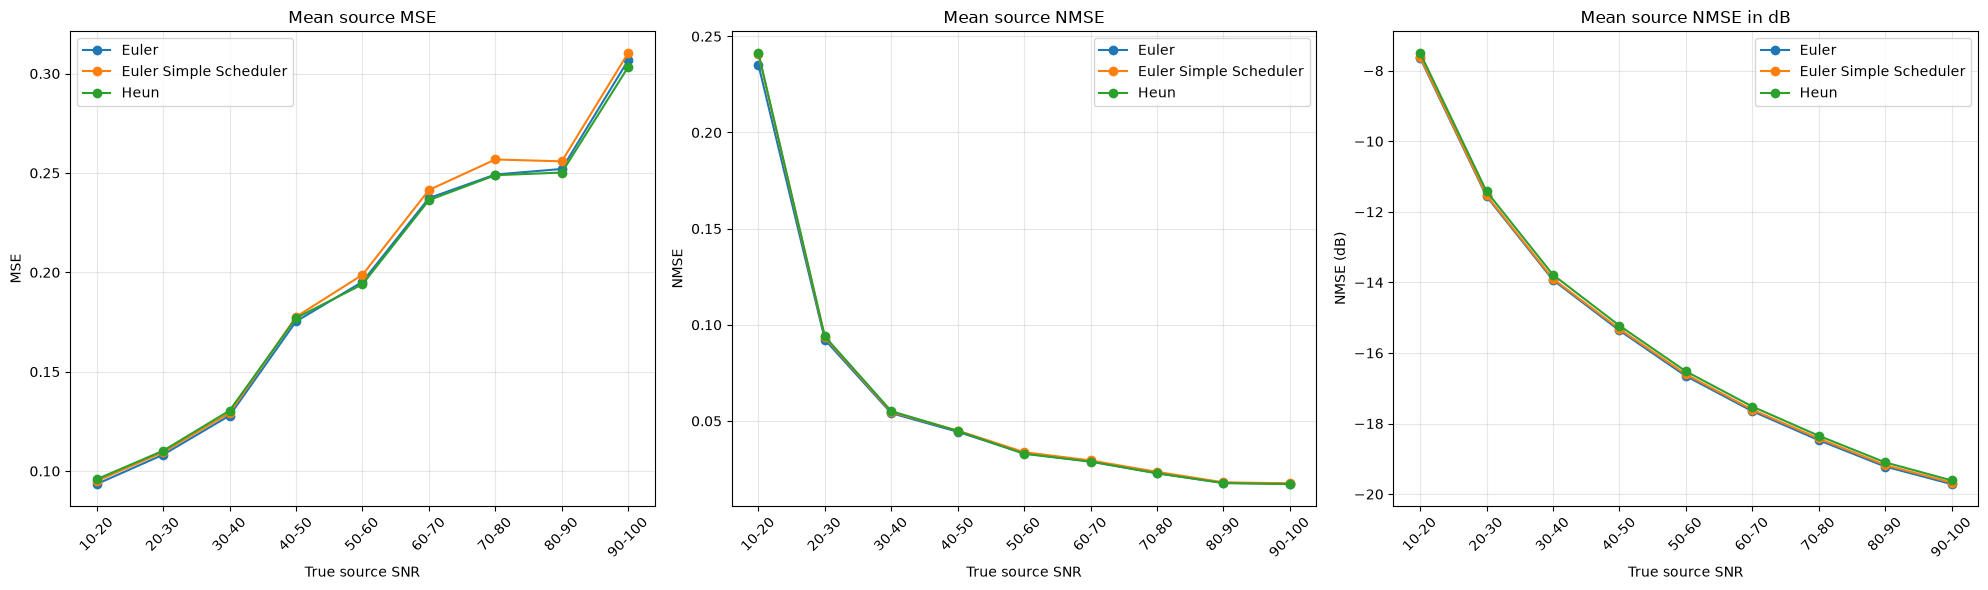

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plots = [
    ("mse", "MSE", "Mean source MSE"),
    ("nmse", "NMSE", "Mean source NMSE"),
    ("nmse_db", "NMSE (dB)", "Mean source NMSE in dB"),
]

for ax, (metric, ylabel, title) in zip(axes, plots):
    for solver, values in snr_metrics.groupby("solver", observed=True):
        ax.plot(
            values["snr_bin"].astype(str),
            values[metric],
            marker="o",
            label=solver,
        )

    ax.set_title(title)
    ax.set_xlabel("True source SNR")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)
    ax.legend()

fig.tight_layout()
plt.show()

In [11]:
# import pickle

# if not Path("results_euler.pkl").exists() or not Path("results_heun.pkl").exists():
#     with open("results_euler.pkl", "wb") as f:
#         pickle.dump(results_euler, f)
#     with open("results_heun.pkl", "wb") as f:
#         pickle.dump(results_heun, f)
# else:
#     with open("results_euler.pkl", "rb") as f:
#         results_euler = pickle.load(f)
#     with open("results_heun.pkl", "rb") as f:
#         results_heun = pickle.load(f)

In [12]:
# import numpy as np
# import matplotlib.pyplot as plt
# import ipywidgets as widgets
# from IPython.display import display
# from scipy.optimize import linear_sum_assignment

# _result_sets = {
#     name: values
#     for name, values in {"Euler": results_euler, "Heun": results_heun}.items()
#     if len(values) > 0
# }
# if not _result_sets:
#     raise RuntimeError("Run the Euler or Heun evaluation cells first.")


# def _align_prediction_with_target(prediction, target):
#     """Align source slots with Hungarian; the residual stays last."""
#     prediction = np.asarray(prediction)
#     target = np.asarray(target)
#     n_sources = target.shape[0] - 1

#     cost = np.mean(
#         (prediction[:n_sources, None] - target[None, :n_sources]) ** 2,
#         axis=(-1, -2),
#     )
#     predicted_slots, target_slots = linear_sum_assignment(cost)

#     aligned = np.empty_like(prediction)
#     for predicted_slot, target_slot in zip(predicted_slots, target_slots):
#         aligned[target_slot] = prediction[predicted_slot]
#     aligned[-1] = prediction[-1]

#     assignment = list(zip(predicted_slots.tolist(), target_slots.tolist()))
#     return aligned, assignment


# solver_widget = widgets.Dropdown(
#     options=list(_result_sets),
#     description="Results:",
# )
# element_widget = widgets.IntSlider(
#     value=0,
#     min=0,
#     max=len(_result_sets[solver_widget.value]) - 1,
#     step=1,
#     description="Element:",
#     continuous_update=False,
#     layout=widgets.Layout(width="650px"),
# )
# previous_button = widgets.Button(description="◀ Previous")
# next_button = widgets.Button(description="Next ▶")


# def _update_element_range(change):
#     element_widget.max = len(_result_sets[change["new"]]) - 1
#     element_widget.value = 0


# def _previous(_):
#     element_widget.value = max(element_widget.min, element_widget.value - 1)


# def _next(_):
#     element_widget.value = min(element_widget.max, element_widget.value + 1)


# solver_widget.observe(_update_element_range, names="value")
# previous_button.on_click(_previous)
# next_button.on_click(_next)


# def _plot_reconstruction(solver, element):
#     result = _result_sets[solver][element]

#     target = np.asarray(result["target"])
#     prediction, assignment = _align_prediction_with_target(
#         result["prediction"],
#         target,
#     )

#     n_slots, n_channels, n_frequency_bins = target.shape
#     frequency_bins = np.arange(n_frequency_bins)
#     source_snrs = np.asarray(result.get("snr", [])).reshape(-1)

#     slot_names = [
#         *[
#             f"Source {source + 1} — SNR={source_snrs[source]:.2f}"
#             if source < len(source_snrs)
#             else f"Source {source + 1} — SNR unavailable"
#             for source in range(n_slots - 1)
#         ],
#         "Residual / noise",
#     ]
#     default_channel_names = ["A real", "A imag.", "E real", "E imag."]
#     channel_names = [
#         default_channel_names[channel]
#         if channel < len(default_channel_names)
#         else f"Channel {channel + 1}"
#         for channel in range(n_channels)
#     ]

#     fig, axes = plt.subplots(
#         n_slots,
#         n_channels,
#         figsize=(4.5 * n_channels, 3.0 * n_slots),
#         sharex=True,
#         squeeze=False,
#     )

#     for slot in range(n_slots):
#         for channel in range(n_channels):
#             ax = axes[slot, channel]
#             ax.plot(
#                 frequency_bins,
#                 target[slot, channel],
#                 label="Target",
#                 linewidth=2,
#             )
#             ax.plot(
#                 frequency_bins,
#                 prediction[slot, channel],
#                 label="Prediction",
#                 linewidth=1.5,
#                 linestyle="--",
#                 alpha=0.9,
#             )
#             ax.set_title(f"{slot_names[slot]} — {channel_names[channel]}")
#             ax.grid(alpha=0.25)
#             if slot == n_slots - 1:
#                 ax.set_xlabel("Frequency bin")
#             if slot == 0 and channel == 0:
#                 ax.legend()

#     stored_loss = float(result.get("loss", np.nan))
#     stored_source_loss = float(result.get("source_loss", np.nan))
#     stored_residual_loss = float(result.get("residual_loss", np.nan))
    
#     fig.suptitle(
#         f"{solver} — element {element}/{len(_result_sets[solver]) - 1}"
#         f" — loss={stored_loss:.6g}"
#         f" — source loss={stored_source_loss:.6g}"
#         f" — residual loss={stored_residual_loss:.6g}"
#         f" — predicted→target PIT: {assignment}",
#         fontsize=14,
#     )
#     fig.tight_layout()
#     plt.show()


# controls = widgets.VBox([
#     widgets.HBox([solver_widget, previous_button, next_button]),
#     element_widget,
# ])
# plots = widgets.interactive_output(
#     _plot_reconstruction,
#     {"solver": solver_widget, "element": element_widget},
# )
# display(controls, plots)
